# Stock market chart pattern recognition using deep learning 


In [ ]:
pip install settrade_v2
pip install cassandra-driver
pip install schedule

Note: you may need to restart the kernel to use updated packages.


# 1. Collect Data(Settrade APi)

In [ ]:
from settrade_v2 import Investor
import pandas as pd
import cassandra
import re
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from cassandra.cluster import Cluster
import requests
from fuzzywuzzy import fuzz
from collections import defaultdict
from fuzzywuzzy import process
from nltk.tokenize import word_tokenize
import requests
import schedule
import time
from cassandra.cluster import Cluster
from datetime import datetime


In [54]:
cluster = Cluster(['127.0.0.1'])  # or 'localhost'
session = cluster.connect()

In [55]:
# กำหนดค่า API Credentials
investor = Investor(
    app_id="a0iOat7M4FrOrGxS",          # เปลี่ยนเป็น App ID ของคุณ
    app_secret="AJcSTgM8JP+N2Uzi6eBGFxnv7i0T6RPzTX+6FiTgfgnp",  # เปลี่ยนเป็น App Secret ของคุณ
    broker_id="SANDBOX",  # เปลี่ยนเป็น Broker ID ของคุณ
    app_code="SANDBOX"
    
)
market = investor.MarketData()


In [56]:
# กรณี Investor
market = investor.MarketData()


res = market.get_candlestick(
    symbol="TRUBB",
    interval="1d",
    limit=1,
    normalized=True,
)

print(res)

{'lastSequence': 0, 'time': [1742317200], 'open': [0.68], 'high': [0.73], 'low': [0.68], 'close': [0.71], 'volume': [1419257], 'value': [1004435.12]}


In [57]:
print(type(res))

<class 'dict'>


In [64]:
# 👉 เชื่อมต่อ Cassandra
cluster = Cluster(['127.0.0.1'])  # Localhost
session = cluster.connect()

# 👉 เลือกใช้ Keyspace
session.set_keyspace('stock_data')

# 👉 ตรวจสอบและสร้างตาราง (ถ้ายังไม่มี)
session.execute("""
    CREATE TABLE IF NOT EXISTS candlestick_data (
        symbol TEXT,
        time TIMESTAMP PRIMARY KEY,
        open_price FLOAT,
        high_price FLOAT,
        low_price FLOAT,
        close_price FLOAT,
        volume INT,
        value FLOAT
    )
""")
print("✅ Keyspace และ Table พร้อมใช้งาน!")

# 👉 ฟังก์ชันดึงข้อมูลหุ้น
def fetch_and_store_stock(symbol="TRUBB", interval="1d", limit=10):
    res = market.get_candlestick(symbol=symbol, interval=interval, limit=limit, normalized=True)

    if not res:
        print(f"⚠️ ไม่พบข้อมูลสำหรับ {symbol}")
        return

    for i in range(len(res["time"])):
        timestamp = datetime.fromtimestamp(res["time"][i])  
        open_price = res["open"][i]
        high_price = res["high"][i]
        low_price = res["low"][i]
        close_price = res["close"][i]
        volume = res["volume"][i]
        value = res["value"][i]

        session.execute("""
            INSERT INTO candlestick_data (symbol, time, open_price, high_price, low_price, close_price, volume, value)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
        """, (symbol, timestamp, open_price, high_price, low_price, close_price, volume, value))

    print(f"✅ เพิ่มข้อมูล {len(res['time'])} รายการของหุ้น {symbol} สำเร็จ!")

# 👉 ทดสอบดึงข้อมูลหุ้น BBL
fetch_and_store_stock(symbol="TRUBB", interval="1d", limit=10)

✅ Keyspace และ Table พร้อมใช้งาน!
✅ เพิ่มข้อมูล 10 รายการของหุ้น TRUBB สำเร็จ!


In [59]:
import time
from datetime import datetime
from cassandra.cluster import Cluster

# ✅ รายชื่อหุ้นที่ต้องการดึงข้อมูล (กำหนดเอง)
symbols = ["TRUBB"]

# ✅ ฟังก์ชันที่ดึงข้อมูล Financial Data สำหรับหุ้นแต่ละตัว
def insert_financial_data(symbol):
    try:
        # 👉 ดึงข้อมูลจาก Settrade API หรือแหล่งข้อมูลอื่น ๆ
        res = market.get_candlestick(symbol=symbol, interval="1d", limit=10, normalized=True)

        if not res:
            print(f"⚠️ ไม่พบข้อมูลสำหรับ {symbol}")
            return

        # 👉 เชื่อมต่อ Cassandra (หรือฐานข้อมูลอื่น ๆ)
        cluster = Cluster(['127.0.0.1'])  # ถ้าเป็น localhost
        session = cluster.connect()
        session.set_keyspace('stock_data')

        # 👉 วนลูปเก็บข้อมูล
        for i in range(len(res["time"])):
            timestamp = datetime.fromtimestamp(res["time"][i])  
            open_price = res["open"][i]
            high_price = res["high"][i]
            low_price = res["low"][i]
            close_price = res["close"][i]
            volume = res["volume"][i]
            value = res["value"][i]

            # 👉 แทรกข้อมูลลงในตาราง
            session.execute("""
                INSERT INTO candlestick_data (symbol, time, open_price, high_price, low_price, close_price, volume, value)
                VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
            """, (symbol, timestamp, open_price, high_price, low_price, close_price, volume, value))

        print(f"✅ เพิ่มข้อมูล {len(res['time'])} รายการของหุ้น {symbol} สำเร็จ!")

    except Exception as e:
        print(f"❌ เกิดข้อผิดพลาดในการดึงข้อมูลของหุ้น {symbol}: {e}")

# ✅ ดึงข้อมูล Financial Data สำหรับหุ้นทุกตัว
for symbol in symbols:
    insert_financial_data(symbol)
    time.sleep(2)  # ⏳ ควบคุม API Rate Limit


✅ เพิ่มข้อมูล 10 รายการของหุ้น TRUBB สำเร็จ!


In [92]:
from cassandra.cluster import Cluster
import pandas as pd

# เชื่อมต่อกับ Cassandra
cluster = Cluster(['127.0.0.1'])  # ระบุ IP ของ Cassandra node ที่คุณใช้งาน
session = cluster.connect('stock_data')  # เปลี่ยนเป็น keyspace ของคุณ

# สั่งเลือกข้อมูลจากตาราง candlestick_data
symbol = "TRUBB"
query = f"SELECT time, open_price, high_price, low_price, close_price FROM candlestick_data WHERE symbol = '{symbol}' ALLOW FILTERING;"

# ดึงข้อมูลจาก Cassandra
rows = session.execute(query)

# สร้าง DataFrame จากผลลัพธ์
data = []
for row in rows:
    data.append({
        "time": row.time,
        "open_price": row.open_price,
        "high_price": row.high_price,
        "low_price": row.low_price,
        "close_price": row.close_price
    })

df = pd.DataFrame(data)

# แสดง DataFrame
print(df)

         time  open_price  high_price  low_price  close_price
0  2024-12-19        1.00        1.01       1.00         1.01
1  2024-10-29        1.10        1.12       1.09         1.11
2  2024-10-04        1.17        1.19       1.16         1.16
3  2024-11-06        1.09        1.12       1.08         1.10
4  2024-11-07        1.10        1.13       1.09         1.09
..        ...         ...         ...        ...          ...
95 2024-10-28        1.11        1.12       1.09         1.09
96 2024-10-10        1.19        1.19       1.17         1.17
97 2024-12-25        1.01        1.06       1.01         1.04
98 2025-03-18        0.70        0.71       0.68         0.69
99 2024-12-17        1.05        1.07       1.01         1.01

[100 rows x 5 columns]


/var/folders/by/j89gc0qj6_zfzkf42sg0dr1c0000gp/T/ipykernel_20461/2436859587.py:30: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



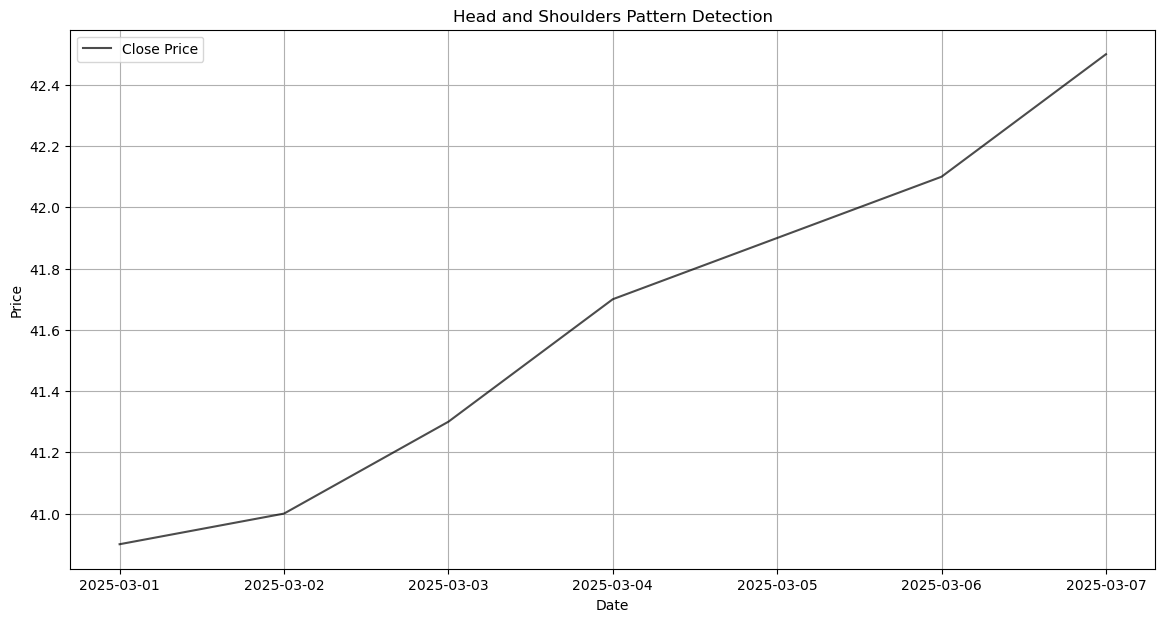

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

# Load DataFrame (assume it's already loaded from Cassandra in the previous steps)
# df = ... (Your DataFrame with columns ['time', 'open_price', 'high_price', 'low_price', 'close_price'])

# Ensure the 'time' column is in datetime format and set it as the index
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

# Step 1: Find local maxima and minima (peaks and troughs)
# Using argrelextrema to find local maxima (1) and minima (0) in 'close_price'
df['local_max'] = df.iloc[argrelextrema(df['close_price'].values, np.greater_equal, order=10)[0]].close_price
df['local_min'] = df.iloc[argrelextrema(df['close_price'].values, np.less_equal, order=10)[0]].close_price

# Step 2: Identify Head and Shoulders Pattern
def detect_head_and_shoulders(df):
    """
    Simple detection of Head and Shoulders pattern in the close price data.
    A basic algorithm for identifying the pattern (not robust).
    """
    # Scan for head and shoulders pattern
    patterns = []

    # Iterate over local maxima and minima
    for i in range(1, len(df) - 1):
        # Check if we have 3 peaks in a row (Left Shoulder, Head, Right Shoulder)
        if not np.isnan(df['local_max'][i - 1]) and not np.isnan(df['local_max'][i]) and not np.isnan(df['local_max'][i + 1]):
            left_shoulder = df['local_max'][i - 1]
            head = df['local_max'][i]
            right_shoulder = df['local_max'][i + 1]

            # Conditions for the Head and Shoulders pattern:
            if left_shoulder < head and right_shoulder < head:
                if left_shoulder > right_shoulder:
                    patterns.append((df.index[i - 1], df.index[i], df.index[i + 1], left_shoulder, head, right_shoulder))

    return patterns

# Step 3: Detect the patterns
patterns = detect_head_and_shoulders(df)

# Step 4: Visualize the results with matplotlib
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['close_price'], label="Close Price", color='black', alpha=0.7)

# Highlight the Head and Shoulders pattern
for pattern in patterns:
    # Plot the left shoulder, head, and right shoulder
    left_shoulder, head, right_shoulder = pattern[3], pattern[4], pattern[5]
    plt.scatter(pattern[0], left_shoulder, color='red', label='Left Shoulder', zorder=5)
    plt.scatter(pattern[1], head, color='green', label='Head', zorder=5)
    plt.scatter(pattern[2], right_shoulder, color='blue', label='Right Shoulder', zorder=5)

# Plot the lines connecting the shoulders and head (Neckline)
    plt.plot([pattern[0], pattern[2]], [left_shoulder, right_shoulder], linestyle='--', color='orange', label="Neckline")

plt.title('Head and Shoulders Pattern Detection')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()
